# Machine Learning

# PKW-Preise schätzen

In diesem Arbeitsblatt wollen wir eine auf Grundlage von Daten, die auf einem Online-Marktplatz für Gebrauchtfahrzeuge [AutoScout24](https://www.autoscout24.de) gesammelt wurden, ein Modell zur Preisvorhersage für PKWs erstellen. Da unsere Zielvariable - der Preis - ein quantitatives Merkmal ist, führen wir eine Regressionsanalyse durch. Die Regression ist ein statistisches Verfahren, mit dem man eine beobachtete, abhängige Variable durch eine oder mehrere unabhängige Variablen zu erklären versucht.
Die **Lineare Regression** ist dabei ein Sonderfall der Regressionsanalyse, bei dem zur Beschreibung der Daten ein lineares Modell herangezogen wird. Das bedeutet, die abhängige Variable wird als Linearkombination der (mit den Regressionskoeffizienten) gewichteten unabhängigen Variablen beschrieben.

Die verwendeten Daten wurden im Mai 2015 für ein Projekt an der ETH Zürich gesammelt.
Der Datensatz liegt als CSV (comma-separated values) Datei vor, einem gängigen Format für tabellarische Daten.
Wir benutzen die Python Bibliothek **Pandas**, um den Datensatz einzulesen und um ihn zu verarbeiten.
Die Funktion `read_csv` importiert eine CSV-Datei in ein `DataFrame` Objekt.
Da der Datensatz einige nicht-ASCII Zeichen enthält, verwenden wir das ISO-8859-1 (Latin-1) Zeichenformat beim Import.
Mit `head(10)` geben wir die ersten 10 Zeilen des Datensatzes aus.

In [7]:
import numpy as np
import pandas as pd
import os
import tarfile
import urllib.request

url = "https://github.com/fh-swf-hgi/ml/raw/main/u2/vw_golf_2015_complete.csv"
dfile = "./vw_golf_2015_complete.csv"

if not os.path.isfile(dfile):
    urllib.request.urlretrieve(url, dfile)
    
df = pd.read_csv("vw_golf_2015_complete.csv", encoding = "ISO-8859-1")
df.head(10)

,marke,modell,preis,kilometer,erstzulassung_monat,erstzulassung_jahr,leistung,treibstoff,mfk_monat,mfk_jahr,...,einparkhilfe_sensoren_vorne,einparkhilfe_sensoren_hinten,radio,alufelgen,sportfahrwerk,sportpaket,anhaengerkupplung,scheckheftgepflegt,nichtraucherfahrzeug,link
0,Volkswagen,Golf 1.4'],2200,95500.0,4.0,2000.0,55,Benzin,3.0,2017.0,...,False,False,True,False,False,False,False,False,True,http://ww3.autoscout24.de/classified/270864412...
1,Volkswagen,Golf Automatik,1000,131400.0,1.0,1991.0,51,Benzin,2.0,2016.0,...,False,False,True,False,False,False,True,False,False,http://ww3.autoscout24.de/classified/270988848...
2,Volkswagen,Golf 1.6'],1700,198700.0,7.0,2000.0,74,Benzin,NaN,NaN,...,False,False,True,False,False,False,False,True,False,http://ww3.autoscout24.de/classified/270990979...
3,Volkswagen,Golf Cabriolet'],2250,226000.0,8.0,1999.0,74,Benzin,2.0,2016.0,...,False,False,True,False,True,False,False,False,False,http://ww3.autoscout24.de/classified/258157992...
4,Volkswagen,Golf GTI,2290,328600.0,5.0,1998.0,110,Benzin,6.0,2016.0,...,False,False,True,False,True,False,False,False,True,http://ww3.autoscout24.de/classified/270939477...
5,Volkswagen,Golf Cabriolet,2450,207000.0,7.0,1996.0,85,Benzin,3.0,2017.0,...,False,False,False,False,False,False,False,False,True,http://ww3.autoscout24.de/classified/270534221...
6,Volkswagen,Golf 4(IV),2790,148000.0,9.0,2001.0,55,Benzin,12.0,2016.0,...,False,False,True,True,False,False,False,True,True,http://ww3.autoscout24.de/classified/270225198...
7,Volkswagen,Golf Cabriolet,2900,150000.0,3.0,2001.0,74,Benzin,12.0,2015.0,...,False,False,False,True,False,False,False,False,False,http://ww3.autoscout24.de/classified/270611026...
8,Volkswagen,Golf 1.6,1950,149000.0,11.0,2000.0,75,Benzin,9.0,2015.0,...,False,False,True,False,False,False,False,True,True,http://ww3.autoscout24.de/classified/270528487...
9,Volkswagen,Golf 1.9,2800,184000.0,12.0,2000.0,74,Diesel,12.0,2015.0,...,False,False,False,False,False,False,False,False,True,http://ww3.autoscout24.de/classified/268338236...


Einige weitere Informationen, z.B. die Namen und Datentypen der Spalten, erhalten wir mit der Funktion `info()`:

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69882 entries, 0 to 69881
Data columns (total 54 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   marke                                69882 non-null  object 
 1   modell                               69882 non-null  object 
 2   preis                                69882 non-null  int64  
 3   kilometer                            64917 non-null  float64
 4   erstzulassung_monat                  62324 non-null  float64
 5   erstzulassung_jahr                   62324 non-null  float64
 6   leistung                             69882 non-null  int64  
 7   treibstoff                           69878 non-null  object 
 8   mfk_monat                            29043 non-null  float64
 9   mfk_jahr                             29043 non-null  float64
 10  angebotsnummer                       69882 non-null  int64  
 11  anbieter                    

Mit `describe()`erhalten wir einige Statistik-Informationen über die Spalten des Datensatzes:

In [9]:
df.describe()

,preis,kilometer,erstzulassung_monat,erstzulassung_jahr,leistung,mfk_monat,mfk_jahr,angebotsnummer,bewertung_durchschnitt,bewertung_gesamteindruck,...,anzahl_bewertungen,prozentsatz_weiterempfehlungen,fahrzeughalter,gaenge,hubraum,kraftstoffverbrauch,co2_emissionen,tueren,sitzplaetze,garantie
count,69882.000000,6.491700e+04,62324.000000,62324.000000,69882.000000,29043.000000,29043.000000,6.988200e+04,58563.000000,58563.000000,...,58563.000000,58563.000000,56954.000000,42429.000000,69072.000000,65130.000000,44715.000000,48772.000000,58961.000000,69882.000000
mean,16684.986806,5.948394e+04,6.221071,2010.262804,88.640981,6.148297,2016.327239,2.667944e+08,3.365206,3.362825,...,6.064341,70.817325,1.116410,5.630606,1556.359060,52.622893,175.159857,4.056897,4.764641,0.519290
std,8770.561579,8.019697e+04,3.255632,5.460235,26.965126,3.195500,0.950245,5.740646e+06,1.834957,1.854903,...,10.841395,40.509073,0.661189,0.665758,300.515149,14.431854,2164.818285,1.025071,0.534224,0.499631
min,785.000000,1.000000e+00,1.000000,1972.000000,8.000000,1.000000,2002.000000,1.225321e+08,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,9999.000000,8.760000e+03,3.000000,2009.000000,77.000000,4.000000,2016.000000,2.655909e+08,3.000000,3.000000,...,1.000000,50.000000,1.000000,5.000000,1390.000000,45.000000,117.000000,4.000000,5.000000,0.000000
50%,17500.000000,2.659500e+04,6.000000,2013.000000,81.000000,6.000000,2016.000000,2.685679e+08,4.220000,4.190000,...,3.000000,95.000000,1.000000,6.000000,1595.000000,51.000000,132.000000,4.000000,5.000000,1.000000
75%,21980.000000,9.550000e+04,9.000000,2014.000000,103.000000,9.000000,2017.000000,2.701202e+08,4.600000,4.660000,...,7.000000,100.000000,1.000000,6.000000,1781.000000,62.000000,157.000000,5.000000,5.000000,1.000000
max,127497.000000,9.999999e+06,12.000000,2015.000000,405.000000,12.000000,2019.000000,2.710579e+08,5.000000,5.000000,...,185.000000,100.000000,10.000000,16.000000,19668.000000,99.000000,127100.000000,6.000000,7.000000,1.000000


Die Datei enthält mit ca. 70.000 Datenpunkten recht viele Einträge.
Für unser Beispiel wollen wir den Datensatz etwas reduzieren.
Dazu wählen wir ein spezielles Automodell aus.
In der folgenden Zelle werden die Spalten *marke* und *modell* ausgewählt und in der resultierenden Tabelle alle doppelten Einträge verworfen. Wir erhalten so einen Dataframe der alle Modelltypen einmalig enthält.

In [10]:
df_typen = df[["marke", "modell"]].drop_duplicates()
df_typen.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 705 entries, 0 to 69817
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   marke   705 non-null    object
 1   modell  705 non-null    object
dtypes: object(2)
memory usage: 16.5+ KB


Die Neue Tabelle enthält 705 unterschiedliche Typen.
Da die Indizes aus der ursprünglichen Tabelle übernommen werden, indizieren wir den neuen Datensatz neu durch.
Von dem resultierenden Dataframe geben wir die ersten 10 Zeilen aus.

In [11]:
df_typen.reset_index(drop=True, inplace=True)
df_typen.loc[:9]

,marke,modell
0,Volkswagen,Golf 1.4']
1,Volkswagen,Golf Automatik
2,Volkswagen,Golf 1.6']
3,Volkswagen,Golf Cabriolet']
4,Volkswagen,Golf GTI
5,Volkswagen,Golf Cabriolet
6,Volkswagen,Golf 4(IV)
7,Volkswagen,Golf 1.6
8,Volkswagen,Golf 1.9
9,Volkswagen,Golf IV


Mit `query("modell=='Golf VI'")` wählen wir die Golf-VI Modelle aus der Liste aus und speichern die Datenpunkte in einen neuen `DataFrame`.

Auch die Anzahl der Merkmale (Spalten) ist mit 54 recht hoch.
Daher reduzieren wir die Spalten des DataFrames auf die 10 Merkmale im Array `merkmale`.

In [12]:
df_golf6 = df.query("modell=='Golf VI'")
df_golf6.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6293 entries, 81 to 69513
Data columns (total 54 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   marke                                6293 non-null   object 
 1   modell                               6293 non-null   object 
 2   preis                                6293 non-null   int64  
 3   kilometer                            6286 non-null   float64
 4   erstzulassung_monat                  6281 non-null   float64
 5   erstzulassung_jahr                   6281 non-null   float64
 6   leistung                             6293 non-null   int64  
 7   treibstoff                           6293 non-null   object 
 8   mfk_monat                            2141 non-null   float64
 9   mfk_jahr                             2141 non-null   float64
 10  angebotsnummer                       6293 non-null   int64  
 11  anbieter                    

## Kategoriale Merkmale umwandeln

Unser Datensatz enthält mehrere Spalten (Merkmale) deren Werte keine "Zahlen" sondern Zeichenketten sind.
In der obigen Ausgabe des DataFrames erkennt man diese Merkmale man Datentyp (`Dtype`) `object`.
Diese sogenannten **kategorialen Variablen** können Zeichenketten oder auch numerische Werte besitzen (beispielsweise 0 = männlich und 1 = weiblich) und kommen in Datensätzen recht häufig vor.
Für Datenanalysen stellen kategoriale (oder *qualitative*) Variable ein gewisses Problem dar, die verwendeten statistischen Methoden erfordern es normalerweise, dass mit Merkmalen *gerechnet* wird und hierzu ist ein Zahlenwert für die einzelnen Merkmale notwendig.

Man könnte auf die Idee kommen, einfach alle vorkommenden Werte einer kategorialen Variable durch zu nummerieren.
Dies ist aber nur dann möglich, wenn die kategoriale Variable *ordinal* ist.
Bei ordinalen Merkamlen lassen sich die Werte der Variablen in eine natürliche Reihenfolge bringen (z. B. Schulnoten von "sehr gut" bis "ungenügend" oder Dienstränge beim Militär).
Ordnet man diesen Kategorieen entsprechende Werte zu, so bleibt die Reihenfolge in durch die Wertigkeiten erhalten.
Häufig sind kategoriale Variable aber *nominal*, d.h. eis gibt keine natürliche Reihenfolge der Werte (z.B. Personennamen oder Steuerklassen).
Nummeriert man die Werte eine nominalen Variablen einfach durch, führt dies in der Regel dazu, dass statistische Verfahren diese "Ordnung" fehlinterpretieren und damit zu falschen Schlussfolgerungen kommen.

Wir müssen also in unserem Datensatz die kategorialen Variablen entweder in metrische Variablen überführen oder bei unseren Analysen ausblenden.
Hierfür gibt es verschiedene Methoden, die wir noch näher betrachten werden.
An dieser Stelle wollen wir eine einfache, aber in der Praxis recht häufig verwendete Technik verwenden, nämlich die sogenannte *One-Hot-Codierung*.
Dabei werden die $N$ unterschiedlichen Werte eines Merkmals durch $N$ separate neue Merkmale $m_1, m_2, \dots, m_N$ dargestellt.
Besitzt ein Datenpunkt bei dem ursprünglichen Merkmal den Wert $y$, so trägt nur das neue Merkmal $m_i$ eine $1$ bei dem das $i$ für den Wert $y$ steht. Alle anderen neuen Merkmale $m_j$ des Datenpunkts tragen den Wert $0$.
Man fasst also die Werte des ursprünglichen Merkmals als eigenständige Merkmale auf und vermerkt für jeden Datenpunkt om der Wert vorliegt oder nicht.

In unserem DataFrame überführen wir nur die kategorialen Variablen, die 10 oder wenige Werte besitzen.
Alle anderen werden wir später verwerfen.
Um die One-Hot-Codierung einer DataFrame Spalte zu erzeugen, verwenden wir hier die Pandas-Funktion `get_dummies`.

In [13]:
df_num = df_golf6
for c in df.select_dtypes(include=['object']).columns:
    print(c, df_num[c].nunique())
    if df_num[c].nunique()<10:
        df_num = pd.get_dummies(df_num, columns = [c])

marke 1
modell 1
treibstoff 5
anbieter 2
karosserieform 7
getriebe 3
antriebsart 3
co2_effizienzklasse 49
schadstoffklasse 58
aussenfarbe 524
innenausstattung 306
link 6293


## Daten Visualisieren und mit Statistischen Kennwerten beschreiben

Als Nächstes möchten wir einen Eindruck erhalten, wie die einzelnen Merkmale miteinander zusammenhängen.
Ist die Anzahl der Merkmale überschaubar, bietet es sich an, **Streudiagramme** (engl. *scatter plot*) für alle Paare von Merkmalen zu zeichnen.

Streudiagramm werden die Elemente zweier Datenreihen paarweise (als X- und Y-Werte) in ein kartesisches Koordinatensystem eingetragen.
Dadurch ergibt sich eine sogenannte Punktwolke, die anzeigt, in welcher Abhängigkeit die beiden Datenreihen zueinander stehen.

Für Python gibt es verschiedene Bibliotheken, mit denen man Streudiagramme zeichnen kann.
Da unsere Daten als Pandas `DataFrame` vorliegen, bietet sich in unserem Fall die Funktion `scatter_matrix` aus dem Paket `pandas.plotting` an.
Da wir in ein kartesisches Koordinatensystem nur numerische Koordinaten eintragen können, reduzieren wir den DataFrame auf Spalten, die entweder als 64-bit `float` oder `int` Typen vorliegen.

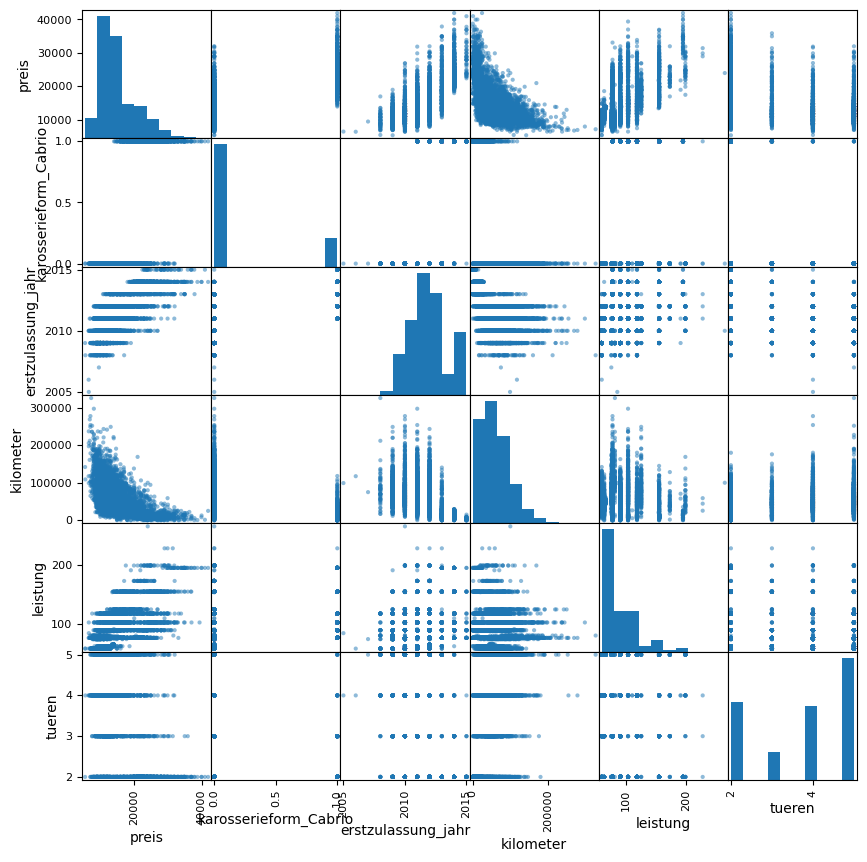

In [14]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

# Wir selektieren einige der Spalten unseres Dataframes...
df_scatter = df_num[['preis', 'karosserieform_Cabrio', 'erstzulassung_jahr','kilometer', 'leistung', 'tueren']]
# ...und erzeugen die Scatter Plots
splot = scatter_matrix(df_scatter, figsize=(10,10));

Die Abbildung zeigt nun eine Vielzahl von *Punktwolken*.
Uns interessiert hier vor allem die erste Zeile (oder die erste Spalte, da die Graphen an der Hauptdiagonalen gespiegelt sind).
Dort sind die Punktwolken abgebildet, bei denen die eine Datenreihe der Preis des Autos ist.
Wir wollen später eine **Schätzfunktion** trainieren, die möglichst gut den Preis eines Gebrauchtfahrzeugs vorhersagen kann.
Daher müssen wir herausfinden, mit welchen anderen Merkmalen der Preis möglichst eng linear *korreliert*.
Grafisch betrachtet, suchen wir nach Punktwolken, die sich möglichst eng anhand **einer** Geraden orientieren.

Erfreulicherweise sind wir nicht auf die visuelle Analyse der Daten angewiesen.
Der **Korrelationskoeffizient** $r$ ist eine Kenngröße, die angibt, wie stark die Werte zweier Datenreihen $x$ und $y$ miteinander linear korrelieren.
Der Wert von $r$ liegt immer in der Grenzen $[-1,1]$.
Dabei bedeutet ein sehr niedriger (etwa $r<-0.8$) oder ein sehr hoher Wert (etwa $r>0.8$), dass die Reihen korrelieren, es also einen statistischen Zusammenhang der Datenreihen gibt.
Ein Wert von $r$ um den Nullpunkt (etwa $-0.5<r<0.5$) bedeutet, dass es keinen signifikanten Zusammenhang gibt.

Für die Berechnung der **Korrelationsmatrix** mit der Pandas Funktion `corr()`, nehmen wir den Datensatz, der alle Merkmale enthält.
Aus der berechneten Matrix selektieren wir die Spalte *Preis* und geben die Korrelationskoeffizienten in absteigend sortierter Reihenfolge aus:

In [15]:
# Wir delektieren aus dem DataFrame df_num nur die "numerischen" Spalten
df_select = df_num.select_dtypes(include=np.number)
corr_matrix = df_select.corr()
corr_matrix["preis"].sort_values(ascending=False)

preis                             1.000000
karosserieform_Cabrio             0.777134
erstzulassung_jahr                0.750210
leistung                          0.565789
mfk_jahr                          0.408306
hubraum                           0.321737
gaenge                            0.276368
getriebe_Automatik                0.273157
garantie                          0.227870
co2_emissionen                    0.197024
kraftstoffverbrauch               0.187224
antriebsart_Allrad                0.129106
prozentsatz_weiterempfehlungen    0.128877
bewertung_angebotsbeschreibung    0.124376
anzahl_bewertungen                0.121461
bewertung_gesamteindruck          0.120119
bewertung_zuverlaessigkeit        0.114964
bewertung_durchschnitt            0.114198
bewertung_erreichbarkeit          0.102644
bewertung_kauferlebnis            0.101971
antriebsart_Front                 0.060969
anbieter_Gewerblicher Anbieter    0.042854
treibstoff_Benzin                 0.028885
karosserief

Da für uns die absolut größten Werte interessant sind, wenden wir die Betragsfunktion `abs()` auf die Werte an und geben die sortierte Liste erneut aus.

In [16]:
corr_matrix["preis"].abs().sort_values(ascending=False).head(10)

preis                       1.000000
karosserieform_Cabrio       0.777134
erstzulassung_jahr          0.750210
kilometer                   0.611772
leistung                    0.565789
tueren                      0.550939
karosserieform_Limousine    0.448258
sitzplaetze                 0.413089
mfk_jahr                    0.408306
hubraum                     0.321737
Name: preis, dtype: float64

**Aufgabe: Berechnen Sie den Korrelationskoeffizienten $\rho$ für die Spalten `preis` und `kilometer` "per Hand"**

Ziehen Sie dazu zuerst aus dem `DataFrame` `temp_df` mit dem Attribut `values` die Werte der (bereinigten) Datenreihen in NumPy Arrays.
Sie können zur Berechnung die NumPy Funktionen `mean()` (für den Mittelwert, bzw. Erwartungswert $\mu$) und `std()` (für die Standardabweichung $\sigma$) benutzen

$ \rho(X,Y) = \Large \frac{cov(X,Y)}{\sigma_X\sigma_Y}$  $\,$   mit  $\,$   $ \large cov(X,Y)=E\left[ (X-\mu_X) (Y-\mu_Y) \right]$

In [17]:
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

In [18]:
# Test Cell
#----------

test_x0 = np.array([  1.,  -4.,   7.,  -6., -14.,  -1.,  -3., -33.,   6.,   3.])
test_y0 = np.array([  2.,  -7., -14.,   3.,  -9.,  19.,  14.,  -3., -11., -23.])

assert cov(test_x0, test_y0) == -18.46

NameError: name 'cov' is not defined

In [19]:
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

In [20]:
# Test Cell
#----------

assert np.around(corrcoef(test_x0, test_y0), 4) == -0.1362

NameError: name 'corrcoef' is not defined

Nun können wir die Funktion `corrcoef` mit unserem Datensatz ausprobieren:

In [21]:
temp_df = df.query("modell=='Golf VI'")[["preis","kilometer"]].dropna()
ty = temp_df["preis"].values
tx = temp_df["kilometer"].values
corrcoef(tx,ty)

NameError: name 'corrcoef' is not defined

NumPy stellt ebenfalls eine Funktion `corrcoef()` zur Verfügung.
Diese stellt die Ergebnisse als Korrelationsmatrix dar, wir können sie aber ungeachtet dessen verwenden, um unser Ergebnis zu überprüfen:

In [22]:
np.corrcoef(tx,ty)

array([[ 1.        , -0.61177151],
       [-0.61177151,  1.        ]])

Um unsere Auto-Daten weiter zu verarbeiten, exportieren wir den relevanten Datensatz in eine CSV-Datei.
CSV steht für **C**omma-**S**eparated **V**alues und ist ein Standardformat um tabellarische Daten textuell zu speichern.

In [23]:
df_select.to_csv("golf6.csv")

## Daten selektieren und aufbereiten
Wir wollen uns für die weitere Analyse auf die Merkmale *karosserieform_Cabrio*, *erstzulassung_jahr*, *kilometer* und *leistung* konzentrieren, da sie die höchste Korrelation mit dem Merkmal *preis* aufweisen.

In [24]:
golf_6_num = df_select[["preis","karosserieform_Cabrio","erstzulassung_jahr","kilometer","leistung"]]
golf_6_num.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6293 entries, 81 to 69513
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   preis                  6293 non-null   int64  
 1   karosserieform_Cabrio  6293 non-null   uint8  
 2   erstzulassung_jahr     6281 non-null   float64
 3   kilometer              6286 non-null   float64
 4   leistung               6293 non-null   int64  
dtypes: float64(2), int64(2), uint8(1)
memory usage: 252.0 KB


Wenn wir den Datensatz auf diese Merkmale reduzieren, fällt auf, dass nicht alle Datenreihen die gleiche Anzahl an Werten beinhalten (siehe Spalte `Non-Null`).
Diese "Lücken" im Datensatz sind kritisch für die weiteren Schritte.
Viele Algorithmen kommen mit unvollständigen Daten, bzw `NaN` Elementen nicht zurecht.
Daher eliminieren wir die Datenpunkte, die ein `NaN` enthalten mit der Funktion `dropna()` aus dem Datensatz.

In [25]:
golf_6_num = golf_6_num.dropna()
golf_6_num.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6281 entries, 81 to 69513
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   preis                  6281 non-null   int64  
 1   karosserieform_Cabrio  6281 non-null   uint8  
 2   erstzulassung_jahr     6281 non-null   float64
 3   kilometer              6281 non-null   float64
 4   leistung               6281 non-null   int64  
dtypes: float64(2), int64(2), uint8(1)
memory usage: 251.5 KB


Wenn wir für die ausgewählten Merkmale Streudiagramme plotten, sehen wir, dass sich für den Preis Abhängigkeiten der Art **"je mehr, desto mehr"** (*erstzulassung_jahr*, *leistung*) sowie **"je mehr, desto weniger"** (*kilometer*) abzeichnen.

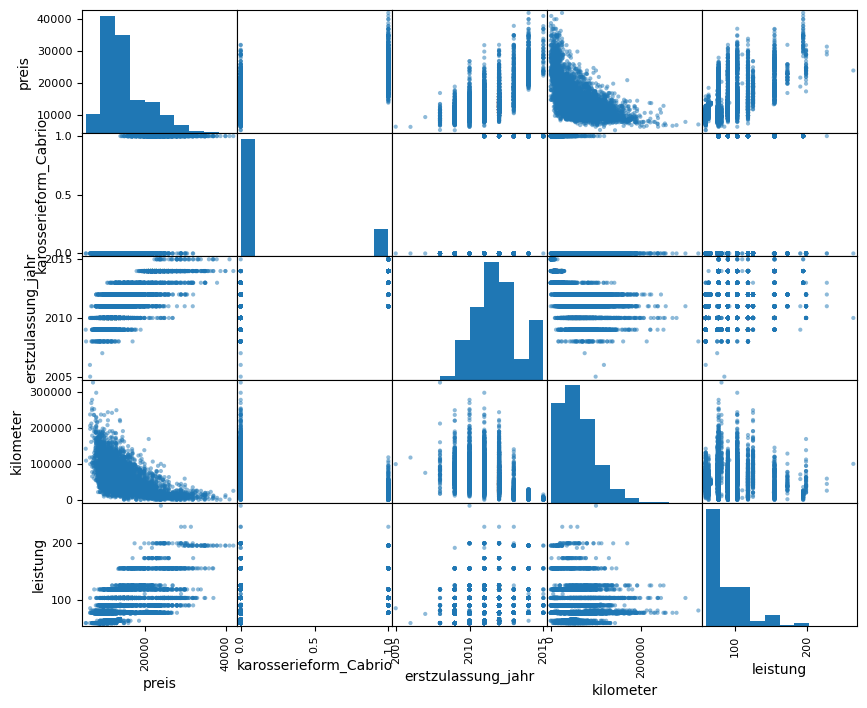

In [26]:
from pandas.plotting import scatter_matrix

scatter_matrix(golf_6_num, figsize=(10, 8));

Als nächstes wollen wir den Datensatz in 2 Teile aufteilen.
Einen **Trainingsdatensatz** sowie einen **Testdatensatz**.
Mit dem ersten *trainieren* wir unser Modell.
Mit dem zweiten Datensatz testen wir die trainierte Modellfunktion.
Mit diesem Ansatz adressieren wir das Problem des **Overfittings** (Überanpassung).
Es kann beim Trainieren des Modells dazu kommen, dass der Lern-Algorithmus die Modell-Parameter zu sehr auf den Trainingsdatensatz anpasst.
Durch vorhalten eines separaten Datensatzes, der nicht zum Trainieren benutzt wird, kann dieses Problem erkannt werden.

Es ist üblich, etwa 1/5 bis 1/3 der Daten für den Trainingsdatensatz und die restlichen Daten für den Testdatensatz zu verwenden.
Um die Daten aufzuteilen verwenden wir die Funktion `train_test_split` aus dem *sklearn* Modul `model_selection`.
Mit dem Parameter `test_size` bestimmen wir den Anteil der Testdaten. Mit `random_state` wird der Zufallszahlengenerator initialisiert, über den die Datenpunkte ausgewählt werden. Legt man `random_state` fest, so wird immer die gleiche Aufteilung vorgenommen. Dies hat den Vorteil, dass die Analysen vergleichbar sind.

In [32]:
from sklearn.model_selection import train_test_split

y = golf_6_num['preis']
# Wir wählen nur die beiden aussagekäftigsten Merkmale aus
X = golf_6_num[["karosserieform_Cabrio","erstzulassung_jahr"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Lineare Regression

Bisher haben wir ausschließlich den Datensatz grafisch und statistisch analysiert, aber noch kein Machine Learning Algorithmus angewendet.
Wir sind jetzt bereit, aus den gesammelten Daten eine *Schätzfunktion* abzuleiten.
Diese Funktion soll auf Grundlage eines oder mehrerer Merkmale eine Schätzung für den Preis des Fahrzeugs ausgeben.
Diese Schätzung soll so ausfallen, dass sie möglichst gut zu den bestehenden Datenpunkten passt.
damit könnte man z.B. der *Richtpreis* für eine neue Annonce berechnen oder bestimmen, ob ein Angebot im Vergleich eher teuer oder günstig ist.
Um diese Schätzfunktion zu entwickeln, stürzen wir uns auf die Zusammenhänge, die wir in der Analysephase herausgearbeitet haben und trainieren auf dieser Grundlage ein lineares Regressionsmodell.

Es ist durchaus möglich, das Regressionsmodell mit den Mitteln, die wir bisher kennengelernt haben (NumPy, Pandas), aufzustellen und zu trainieren.
Um die Trainingsalgorithmen kennenzulernen, werden wir das zu einem späteren Zeitpunkt auch tun.
Allerdings ist es in der Praxis eher unüblich, Machine Learning (ML) Modelle "per Hand" zu entwickeln.
Es gibt, insbesondere für Python, eine Vielzahl von Bibliotheken, mit denen ML Modelle effizient trainiert werden können.

Eine weit verbreitete ML Bibliothek für Python ist **Scikit-Learn** (oder auch *sklearn*).
Eine Besonderheit von Scikit-Learn ist, dass die Bibliothek sehr umfassend ist und ein breites Spektrum von ML-Algorithmen unterstützt.
Darunter sind Algorithmen zur Klassifikation, Regression und für das Clustering.
Auch unterstützende Methode wie etwa Algorithmen zur Dimensionsreduktion, zur Modellauswahl und zur Vorverarbeitung der Rohdaten sind in der Bibliothek enthalten.

Die Funktionen zur linearen Regression entnehmen wir aus dem Modul `sklearn.linear_model`.
Zur besseren Übersicht, weisen wir die abhängige Variable auf `y` (bzw. `y_test`) zu, die unabhängige Variable auf `X` (bzw. `X_test`)

Wir erzeugen mit `lin_reg` ein Modell als Objekt der Klasse `LinearRegression` und trainieren das Modell mit dem Aufruf `fit(X,y)` auf unsere Daten.

In [33]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression().fit(X_train, y_train)

Nun haben wir das Modell trainiert, aber wie gut passt es zu unserem Datensatz?
Eine Antwort aus diese Frage kann uns der durchschnittlichen Fehler für unseren Trainingsdatensatz geben.
Die Funktion `mean_absolute_error` berechnet den Mittelwert der absoluten Fehler für die Schätzung.

Damit wir mehrere Modelle schneller untersuchen können, schreiben wir eine Funktion `eval_model` die auf Grundlage der Testdaten (`X_test`) sowie der zugehörigen tatsächlichen Ergebnisse der Testdaten (`y_test`) einen *Schätzer* (`model`) untersucht.

In [34]:
from sklearn.metrics import mean_absolute_error

def eval_model(model, X_test, y_test):
    avg_price = y_test.values.mean()
    print("Mittlerer Preis: %d EUR" % avg_price)

    pred_err = mean_absolute_error(y_test,model.predict(X_test))
    pred_err_pc = pred_err*100//avg_price
    print(f"Im Mittel liegt die Preisschätzung um {pred_err:.2f}€ oder {pred_err_pc:.1f}% daneben")
    

Nun rufen wir `eval_model` mit unserem Modell `lin_reg` auf:

In [35]:
eval_model(lin_reg, X_test, y_test)

Mittlerer Preis: 14976 EUR
Im Mittel liegt die Preisschätzung um 2248.58€ oder 15.0% daneben


Eine mehr als 10%-ige Abweichung von Preis ist nicht unbedingt gut.
Wir können das Ergebnis verbessern, indem wir mehr Variablen in das Modell aufnehmen.

**Aufgabe: Trainieren Sie ein LinearRegression-Modell mit allen Merkmalen des Datensatzes `golf_6_num`. Wie gut kann das Modell den erwarteten Preis vorhersagen?**


In [40]:
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

y = golf_6_num['preis']
X = golf_6_num[['kilometer','leistung','erstzulassung_jahr']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

                  
lin_reg2 = LinearRegression()
lin_reg2.fit(X_train, y_train)

avg_price = y_test.values.mean()
print("Mittlerer Preis: %d EUR" % avg_price)

pred = lin_reg2.predict(X_test)
pred_err = mean_absolute_error(y_test,pred)
pred_err_pc = pred_err*100//avg_price

print("Mittlerer Fehler bei der Vorhersage: %d EUR (oder %d%%)" % (pred_err, pred_err_pc))

Mittlerer Preis: 14976 EUR
Mittlerer Fehler bei der Vorhersage: 1628 EUR (oder 10%)


**Aufgabe: Verwenden Sie weitere Regressionsverfahren um die Ergebnisse mit dem Linear-Regression-Modell zu vergleichen**

*sklearn* bietet noch weitere Klassen für Regressionsanalysen. Darunter etwa `sklearn.linear_modelElasticNet`, `sklearn.ensemble.GradientBoostingRegressor` und `sklearn.tree.DecisionTreeRegressor`.
Verwenden Sie diese Modelle und vergleichen Sie die Ergebnisse mit dem Modell oben zu vergleichen. Welches Verfahren liefert die besten Ergebnisse?

In [41]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split

y = golf_6_num['preis']
X = golf_6_num[['kilometer','leistung','erstzulassung_jahr']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

                  
lin_elast = ElasticNet()
lin_elast.fit(X_train, y_train)

avg_price = y_test.values.mean()
print("Mittlerer Preis: %d EUR" % avg_price)

pred = lin_elast.predict(X_test)
pred_err = mean_absolute_error(y_test,pred)
pred_err_pc = pred_err*100//avg_price

print("Mittlerer Fehler bei der Vorhersage: %d EUR (oder %d%%)" % (pred_err, pred_err_pc))

Mittlerer Preis: 14976 EUR
Mittlerer Fehler bei der Vorhersage: 1674 EUR (oder 11%)


In [43]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

y = golf_6_num['preis']
X = golf_6_num[['kilometer','leistung','erstzulassung_jahr']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

                  
lin_grad = GradientBoostingRegressor()
lin_grad.fit(X_train, y_train)

avg_price = y_test.values.mean()
print("Mittlerer Preis: %d EUR" % avg_price)

pred = lin_grad.predict(X_test)
pred_err = mean_absolute_error(y_test,pred)
pred_err_pc = pred_err*100//avg_price

print("Mittlerer Fehler bei der Vorhersage: %d EUR (oder %d%%)" % (pred_err, pred_err_pc))

Mittlerer Preis: 14976 EUR
Mittlerer Fehler bei der Vorhersage: 1204 EUR (oder 8%)


In [44]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

y = golf_6_num['preis']
X = golf_6_num[['kilometer','leistung','erstzulassung_jahr']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

                  
lin_dec = DecisionTreeRegressor()
lin_dec.fit(X_train, y_train)

avg_price = y_test.values.mean()
print("Mittlerer Preis: %d EUR" % avg_price)

pred = lin_dec.predict(X_test)
pred_err = mean_absolute_error(y_test,pred)
pred_err_pc = pred_err*100//avg_price

print("Mittlerer Fehler bei der Vorhersage: %d EUR (oder %d%%)" % (pred_err, pred_err_pc))

Mittlerer Preis: 14976 EUR
Mittlerer Fehler bei der Vorhersage: 1631 EUR (oder 10%)
